<h1 align = "center">
Rwanda Maize-Urea Trial
</h1>

<h2 align = "center">
Phase 1: Data Audit - What issues exist?
</h2>

# Phase 1 Objectives

The data audit phase is intended to establish the structure, grain, quality and relationship of the datasets created during the Rwanda Maize-Urea field trial.

At the end of this audit exercise, we should be able to answer the following questions:

1. **What exactly is contained in each dataset?**

2. **What does a row represent in each dataset?**

3. **How are the datasets related?** and

4. **Are there any structural/data-quality issues that could affect subsequent analysis?**

We want to divide the data audit exercise into six major audits:

1. Data inventory
2. Structure and grain understanding
3. Data types identification
4. Keys, uniqueness and relationships
5. Missingness and completeness
6. Experimental-design and logical checks

Through these audit steps, we are interested in assessing:

- data dimensions
- variable structure
- data types
- missing values
- duplicates
- uniqueness of identifiers
- relationship between datasets
- experimental structure
- logical consistency of key variables


> This exercise does not involve cleaning the data just yet; We're just interested in **discovering and documenting problems**, not fixing them yet

At this point we've established that our project repository structure will be something like this:

    rwanda-maize-urea-analysis/
    │
    ├── 01_Data/
    │   ├── raw/
    │   ├── external/
    │   └── processed/
    │
    ├── 02_Notebooks/
    │
    ├── 03_Scripts/
    │
    ├── 04_Outputs/
    │   ├── figures/
    │   ├── tables/
    │   └── models/
    │
    ├── 05_Report/
    │
    ├── 06_Dashboard/
    │   ├── images/
    │   └── screenshots
    │
    └── README.md


Therefore, we should first have our original datasets 
- `Field_Level`
- `Plot_Level` and
- `Soil_PL`

in our data/raw folder.

 > We don't want to modify these raw files; That's important for reproducibility
 > Raw data must remain untouched - transformations should happen through code.

# Import Python Libraries

For now, we'll keep this deliberately small

In [1]:
import pandas as pd
import numpy as np

Later, we can introduce other libraries, including, but not limited to:
- `matplotlib`
- `seaborn`
- `scipy`
- `statsmodels`
- `sklearn`
- `geopandas`, etc.

But we're refraining from importing everything at the begining to maintain a professional outlook

Remember, a good analytical notebook introduces dependencies when they're actually needed.

## Load Datasets

We can opt to upload the datsets by typing in the path to the datasets each time or use a cleaner option:
    
- Since we have all the necessary datasets in one folder, we can opt for loading the data using a cleaner path

 - We'll need to define the dataset path first and then load each data frame using a shorter code each time we want to read. 

Alternatively, an even cleaner option would be to load the datasets using a  helper function in pathlib. 

We'll opt for this second approach instead.

In [2]:
from pathlib import Path

# We define the path to folder
data_path = Path(r"../01_Data/raw")

def load_csv (filename):
    return pd.read_csv(data_path/filename)

# Now we use it to access the datasets

field_df = load_csv("Field_Level.csv")
plot_df = load_csv("Plot_Level.csv")
soil_df = load_csv("Soil_PL.csv")

Before we start auditing the dataframes we have column by column, we want to establish the size of each dataset:

- We want to look at a few things that will point us to the direction of what to look for:

Essentially, we want to look at the shape of the respective datasets.

- The shape of a dataset helps us know the number of fields and records we have in the dataframe. 
- Dataset dimensions establish the scale of the available data and provide the starting point for subsequent structural, completeness and relationship checks. 
    - They establish the scale of each dataset, while subsequent grouping and frequency analyses will be used to assess balance and experimental representation.
- We'll create a small inventory table.
 

In [3]:
datasets = {
    "Field" : field_df,
    "Plot" : plot_df,
    "Soil" : soil_df   
}
   
inventory = []

for name, df in datasets.items():
    inventory.append({
        "dataset": name,
        "rows": df.shape[0],
        "columns": df.shape[1]
    })

inventory_df = pd.DataFrame(inventory)

inventory_df

,dataset,rows,columns
0,Field,399,19
1,Plot,1598,27
2,Soil,736,5


## Column Audit


What we are interested to see here is whethere there exists any suspicious variables. 

We'll be looking for variables that have been stored wrongly. For example:

- numeric variables stored as string
- datetime variables stored as string
- string variables stored as object etc.

#### Field Dataset

Let's start by identifying the columns listed in each dataset to see if it matches what's in the codebook

In [4]:
field_df.columns

Index(['block_id', 'season', 'district', 'cell', 'agzone', 'meg_env', 'lat',
       'long', 'alt', 'landscape_pos', 'slope_pos', 'fert_rank', 'soil_color',
       'rockness', 'soil_depth', 'slope', 'trial_follower_gender',
       'trialfield_home_min', 'cult_land'],
      dtype='str')

Now we make the audit more usefull. We identify:
-  column names
- non-null counts
- data types

In [5]:
display(field_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   block_id               399 non-null    str    
 1   season                 399 non-null    str    
 2   district               399 non-null    str    
 3   cell                   399 non-null    str    
 4   agzone                 399 non-null    str    
 5   meg_env                399 non-null    str    
 6   lat                    399 non-null    float64
 7   long                   399 non-null    float64
 8   alt                    399 non-null    float64
 9   landscape_pos          399 non-null    str    
 10  slope_pos              242 non-null    str    
 11  fert_rank              399 non-null    str    
 12  soil_color             399 non-null    str    
 13  rockness               242 non-null    str    
 14  soil_depth             242 non-null    str    
 15  slope            

None

##### Key results

Column                | Non-Null      | Expected Dtype  | Actual Dtype | Issue 
----------------------|---------------|-----------------|--------------|------
block_id              | 399           |string           |string        |
season                | 399           |string           |string        |
district              | 399           |string           |string        |
cell                  | 399           |string           |string        |
agzone                | 399           |string           |string        |
meg_env               | 399           |string           |string        |
lat                   | 399           |float            |float         |
long                  | 399           |float            |float         |
alt                   | 399           |float            |float         |
landscape_pos         | 399           |string           |string        |
slope_pos             | 242           |string           |string        |Substantial null records existing
fert_rank             | 399           |string           |string        |
soil_color            | 399           |string           |string        |
rockness              | 242           |string           |string        |Substantial null records existing
soil_depth            | 242           |string           |string        |Substantial null records existing
slope                 | 399           |integer          |integer       |
trial_follower_gender | 390           |string           |string        |A few null records existing
trialfield_home_min   | 118           |float            |float         |Substantial null records existing
cult_land             | 390           |float            |float         |A few null records existing




We can see that:

- No obvious data-type mismatch was identified in the Field dataset, and

- Although most field variables are completely populated, several variables exhibit substantial missingness, particularly `trialfield_home_min`, `slope_pos`, `rockness` and `soil_depth`. 

    - These variables require separate missingness assessment.

In [6]:
display(field_df.head())

,block_id,season,district,cell,agzone,meg_env,lat,long,alt,landscape_pos,slope_pos,fert_rank,soil_color,rockness,soil_depth,slope,trial_follower_gender,trialfield_home_min,cult_land
0,adfa31ad-95bf-453d-94f1-d163a97756ee,21A,Rwamagana,Akanzu,Eastern Ridges,Low-Mid-Dry,-2.021072,30.334707,1638.04,Hills,Backslope,medium,red_less,no_rocks,shallow,3,Male,4.0,20.0
1,d8807f25-e675-49ae-87a3-d228eca23c72,21A,Rwamagana,Akanzu,Eastern Ridges,Low-Mid-Dry,-2.021166,30.334817,1622.55,Hills,Backslope,medium,red_more,less_rocky,shallow,4,Male,5.0,19.0
2,262efa71-6ff4-4e18-b6f1-0c3d293504c0,21A,Rwamagana,Akanzu,Eastern Ridges,Low-Mid-Dry,-2.020386,30.338258,1610.46,Hills,Backslope,medium,red_less,no_rocks,deep,3,Male,15.0,18.0
3,95c016dd-908a-4f07-9e49-926e9a9f4f19,21A,Rwamagana,Akanzu,Eastern Ridges,Low-Mid-Dry,-2.020589,30.337583,1620.42,Hills,Backslope,medium,red_less,no_rocks,deep,3,Male,3.0,18.0
4,1d5c61a0-ca6b-4db8-87c3-5ca46c7cad6d,21A,Rwamagana,Akanzu,Eastern Ridges,Low-Mid-Dry,-2.018119,30.338658,1614.13,Hills,Backslope,medium,black_less,less_rocky,shallow,4,Female,5.0,10.0


A glimpse of the dataframe indicates that the values are correctly stored for each field

#### Plot Dataset

Now let's do the same for the plot dataset

In [7]:
plot_df.columns

Index(['block_id', 'season', 'plot_id', 'treat_code', 'treat_details',
       'urea_rate_timing', 'crop', 'prior_season_crop', 'planting_date',
       'compost_tha', 'compost_quality', 'seed_variety', 'seeds_kgha',
       'dap_kgha', 'urea_planting_kgha', 'germ_count_date', 'germination_rate',
       'urea_V6_date', 'urea_V6_kgha', 'urea_V10_date', 'urea_V10_kgha',
       'urea_total_kgha', 'N_kgha', 'silking_date', 'R3_date', 'harvest_date',
       'yield_tha'],
      dtype='str')

In [8]:
  
display(plot_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1598 entries, 0 to 1597
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   block_id            1598 non-null   str    
 1   season              1598 non-null   str    
 2   plot_id             1598 non-null   str    
 3   treat_code          1598 non-null   str    
 4   treat_details       1598 non-null   str    
 5   urea_rate_timing    1598 non-null   str    
 6   crop                1598 non-null   str    
 7   prior_season_crop   1138 non-null   str    
 8   planting_date       1598 non-null   str    
 9   compost_tha         1598 non-null   int64  
 10  compost_quality     1590 non-null   str    
 11  seed_variety        1598 non-null   str    
 12  seeds_kgha          1598 non-null   int64  
 13  dap_kgha            1598 non-null   int64  
 14  urea_planting_kgha  1598 non-null   int64  
 15  germ_count_date     1598 non-null   str    
 16  germination_rate 

None

In [9]:
display(plot_df.head())

,block_id,season,plot_id,treat_code,treat_details,urea_rate_timing,crop,prior_season_crop,planting_date,compost_tha,...,urea_V6_date,urea_V6_kgha,urea_V10_date,urea_V10_kgha,urea_total_kgha,N_kgha,silking_date,R3_date,harvest_date,yield_tha
0,adfa31ad-95bf-453d-94f1-d163a97756ee,21A,adfa31ad-95bf-453d-94f1-d163a97756ee-21A-A,A,DAP 1Kg/Are + Urea 0.5Kg/Are at V6,Urea 0.5Kg/Are(V6),maize,maize,9/26/2020,8,...,11/11/2020,50,NaN,0,50,41,12/24/2020,1/13/2021,2/24/2021,4.52
1,adfa31ad-95bf-453d-94f1-d163a97756ee,21A,adfa31ad-95bf-453d-94f1-d163a97756ee-21A-B,B,DAP 1Kg/Are + Urea 0.5Kg/Are at Planting and U...,Urea1kg/Are(Planting+V6),maize,maize,9/26/2020,8,...,11/11/2020,50,NaN,0,100,64,12/24/2020,1/13/2021,2/24/2021,4.20
2,adfa31ad-95bf-453d-94f1-d163a97756ee,21A,adfa31ad-95bf-453d-94f1-d163a97756ee-21A-C,C,DAP 1Kg/Are + Urea 0.5Kg/Are at V6 + Urea 0.5K...,Urea 1kg/Are(V6 + V10),maize,maize,9/26/2020,8,...,11/11/2020,50,12/3/2020,50,100,64,12/24/2020,1/13/2021,2/24/2021,3.49
3,adfa31ad-95bf-453d-94f1-d163a97756ee,21A,adfa31ad-95bf-453d-94f1-d163a97756ee-21A-D,D,DAP 1Kg/Are at planting+ Urea 1Kg/Are at V6,Urea 1kg/Are(V6),maize,maize,9/26/2020,8,...,11/11/2020,100,NaN,0,100,64,12/24/2020,1/13/2021,2/24/2021,3.58
4,d8807f25-e675-49ae-87a3-d228eca23c72,21A,d8807f25-e675-49ae-87a3-d228eca23c72-21A-A,A,DAP 1Kg/Are + Urea 0.5Kg/Are at V6,Urea 0.5Kg/Are(V6),maize,maize,9/26/2020,10,...,11/11/2020,50,NaN,0,50,41,12/24/2020,1/13/2021,2/24/2021,4.59


##### Key Results

Column             | Non-Null | Expected Dtype | Actual Dtype | Issue
-------------------|----------|----------------|--------------|----------  
block_id           | 1598     | string         | string       | 
season             | 1598     | string         | string       |
plot_id            | 1598     | string         | string       |
treat_code         | 1598     | string         | string       |
treat_details      | 1598     | string         | string       |
urea_rate_timing   | 1598     | string         | string       |
crop               | 1598     | string         | string       |
prior_season_crop  | 1138     | string         | string       |
planting_date      | 1598     | date           | string       | Incorrect data type stored
compost_tha        | 1598     | integer        | integer      |
compost_quality    | 1590     | string         | string       |
seed_variety       | 1598     | string         | string       |
seeds_kgha         | 1598     | integer        | integer      |
dap_kgha           | 1598     | integer        | integer      |
urea_planting_kgha | 1598     | integer        | integer      |
germ_count_date    | 1598     | date           | string       | Incorrect data type stored
germination_rate   | 1598     | integer        | integer      |
urea_V6_date       | 1598     | string         | string       |
urea_V6_kgha       | 1598     | integer        | integer      |
urea_V10_date      | 286      | date           | string       | Incorrect data type stored; substantial missing values
urea_V10_kgha      | 1598     | integer        | integer      |
urea_total_kgha    | 1598     | integer        | integer      |
N_kgha             | 1598     | integer        | integer      |
silking_date       | 1589     | date           | string       | Incorrect data type stored
R3_date            | 1592     | date           | string       | Incorrect data type stored; a few missing values
harvest_date       | 1598     | date           | string       | Incorrect data type stored
yield_tha          | 1598     | float          | float        |




- We realize that in the plot dataset there are a few fields with data stored in the wrong formats: 

    - *planting_date, germ_count_date, urea_V6_date, urea_V10_date, silking_date, R3_date and harvest_date* have been stored as string variables instead of datetime. 

- These variables have been identified as data-preparation requirements. Their values should first be validated for date consistency before conversion to datetime during the preparation phase.

#### Soil Dataset

- Now we do the same for the soil dataset

In [10]:
soil_df.columns

Index(['plot_id', 'pH', 'tot_N', 'org_C', 'sand'], dtype='str')

In [11]:
display(soil_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   plot_id  736 non-null    str    
 1   pH       734 non-null    float64
 2   tot_N    0 non-null      float64
 3   org_C    0 non-null      float64
 4   sand     0 non-null      float64
dtypes: float64(4), str(1)
memory usage: 28.9 KB


None

In [12]:
display(soil_df.head())

,plot_id,pH,tot_N,org_C,sand
0,adfa31ad-95bf-453d-94f1-d163a97756ee-21A-A,5.21,NaN,NaN,NaN
1,d8807f25-e675-49ae-87a3-d228eca23c72-21A-A,5.75,NaN,NaN,NaN
2,262efa71-6ff4-4e18-b6f1-0c3d293504c0-21A-A,5.81,NaN,NaN,NaN
3,95c016dd-908a-4f07-9e49-926e9a9f4f19-21A-A,5.75,NaN,NaN,NaN
4,1d5c61a0-ca6b-4db8-87c3-5ca46c7cad6d-21A-A,6.13,NaN,NaN,NaN


##### Key Results

 Column  | Non-Null       | Expected Dtype | Actual Dtype  | Issue
---------|----------------|----------------|---------------|----------  
plot_id  | 736 non-null   | string         | string        |
pH       | 734 non-null   | float          | float         | A few missing values
tot_N    | 0 non-null     | float          | float         | Totally empty field
org_C    | 0 non-null     | float          | float         | Totally empty field
sand     | 0 non-null     | float          | float         | Totally empty field


- We can learn from the output above that *tot_N, org_C and sand* columns are completely empty

    - The complete absence of tot_N, org_C and sand means these variables cannot currently contribute to analysis without additional data. 
    
        - External soil information may therefore be considered during the data-enrichment phase, subject to assessing its suitability and spatial compatibility with the trial locations

## Dataset Grain


### Field Grain

We want to establish the grain of each dataset
- We expect block_id in field dataset to identify a field per season
- Based on our understanding of the project, each row is supposed to represent one trial field in one season.

In [13]:
field_df["block_id"].nunique()

399

In [14]:
field_df.shape[0]

399

Comparing the two, we  realize the output is identical
- This is encouraging, and confirms our hypothesis that `block_id` is unique across the 399 Field_Level records, with no duplicate `block_id` values. 
    - The combination of `block_id` and `season` is also unique. 
    - Therefore, the current dataset supports a one-row-per-field observation structure, with `block_id` functioning as a unique field identifier in the research data..
- We now check for whether there are duplicate rows in the field dataset

In [15]:
field_df["block_id"].duplicated().sum()

np.int64(0)

The output confirms there are no dupplicate records.
- But we have to ask whether block_id can repeat across seasons
    - We can't assume that block_id is necessarily the complete key
        - so we test block_id + season to uniquely identify field-season observation

In [16]:
field_df.duplicated(subset=["block_id", "season"]).sum()

np.int64(0)

No we can be certain there are no duplicate block_id even by season.

### Plot Grain

We repeat the steps for plot dataset, now testing uniqueness by `plot_id`

In [17]:
plot_df["plot_id"].nunique()

1598

In [18]:
plot_df.shape[0]

1598

In [19]:
plot_df.duplicated(subset=["block_id","season","plot_id"]).sum()

np.int64(0)

Again, proof there are no duplicate records;

- The Plot_Level dataset contains 1,598 unique plot observations, with no duplicate records on the proposed (`block_id`, `season`, `plot_id`) key.

### The four-plots-per-field hypothesis

From the experiment, each field was supposedly divided into four plots
- It's important that we check whether the actual data supports this
    - This an important experimental-design check:
        

In [20]:
plots_per_field = (
    plot_df.groupby(["block_id", "season"])["plot_id"]
        .nunique()
)

plots_per_field.value_counts().sort_index()

plot_id
2      1
3      4
4    396
Name: count, dtype: int64

The output suggests:
- 396 field-season combinations contain four plots
- 4 field-season combinations contain 3 plots, and
- 1 field-season combination contain 2 plots

The experimental structure is largely consistent with the stated four-plot-per-field design, but five field-season combinations are incomplete. 

- These incomplete experimental units require investigation before treatment-effect analysis because they may affect within-field treatment comparisons and statistical power.

### Treatment allocation check

The experiment supposedly contains four treatments
-  we want to see what is actually present

In [21]:
plot_df["urea_rate_timing"].value_counts(dropna=False)

urea_rate_timing
Urea 1kg/Are(V6 + V10)      401
Urea 1kg/Are(V6)            401
Urea 0.5Kg/Are(V6)          399
Urea1kg/Are(Planting+V6)    397
Name: count, dtype: int64

In [22]:
plot_df["urea_rate_timing"].nunique()

4

As expected, there are 4 treatment categories.

However, the next question is whether each field actually contains all four treatments

In [23]:
treatment_counts = (
    plot_df.groupby(["block_id", "season"])["urea_rate_timing"]
        .nunique()
)

treatment_counts.value_counts().sort_index()

urea_rate_timing
2      1
3      4
4    396
Name: count, dtype: int64

We can see then that:
- 396 fields have all four treatments,
- 4 have three treatments, and
- 1 has two treatments.

This is going to be essential for the experimental analysis.

##### Interpretation

The incomplete field-season units have now been identified, including the specific treatment categories absent from each unit.

That means these five units deserve specific investigation.

We need to find:

* which fields they are;
* which treatments are missing;
* which seasons/ME they belong to;
* whether the missing treatment is genuinely absent or incorrectly recorded.

### Treatment x plot structure check

We now go one step further and inspect how treatments are distributed within fields

What we want to establish is whether the experimental design described in the project dosumentation is actually reflected in the raw data.

In [24]:
plot_df.groupby(
    ["block_id", "season"]
)["urea_rate_timing"].value_counts()

block_id                              season  urea_rate_timing        
014d6b73d08a42c1be8990d884b17206      22A     Urea 0.5Kg/Are(V6)          1
                                              Urea1kg/Are(Planting+V6)    1
                                              Urea 1kg/Are(V6 + V10)      1
                                              Urea 1kg/Are(V6)            1
02a456dc-95f9-4e68-8187-f67031bcb563  21A     Urea 0.5Kg/Are(V6)          1
                                                                         ..
ff120793-f8d1-42dd-a0ba-d577cfd102e9  21A     Urea 1kg/Are(V6)            1
ff5a2b55-7060-4351-adf1-7de40fd9009c  21A     Urea 0.5Kg/Are(V6)          1
                                              Urea1kg/Are(Planting+V6)    1
                                              Urea 1kg/Are(V6 + V10)      1
                                              Urea 1kg/Are(V6)            1
Name: count, Length: 1598, dtype: int64

## Missingness Audit

While any research would be aiming to collect records for all variables, it is important to acknowledge that in a real-world scenario, it may be challenging to all records as expected.

- In auditing the datasets for missingness, our interest is to not only assess whether there are missing variables, but to also ascertain how much of the records are missing for each variable.

- We're intereted in assessing the percentage of missing variables for each variable with missingness. 

    - A good rule of thumb is to not only flag out variables with missing records, but to also ascertain what percentage is missing. Possibly even visualize the missingness.



Field


trialfield_home_min      70.426065
slope_pos                39.348371
soil_depth               39.348371
rockness                 39.348371
trial_follower_gender     2.255639
cult_land                 2.255639
dtype: float64

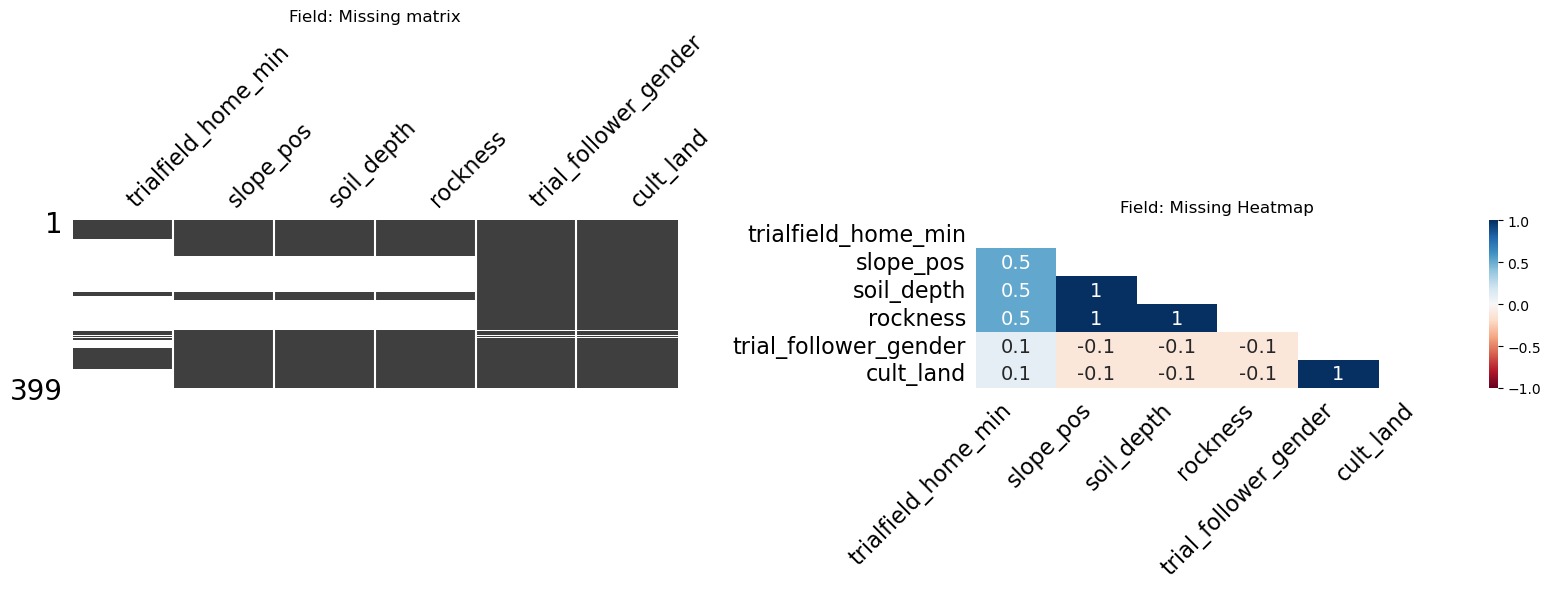



Plot


urea_V10_date        82.102628
prior_season_crop    28.785982
silking_date          0.563204
compost_quality       0.500626
R3_date               0.375469
dtype: float64

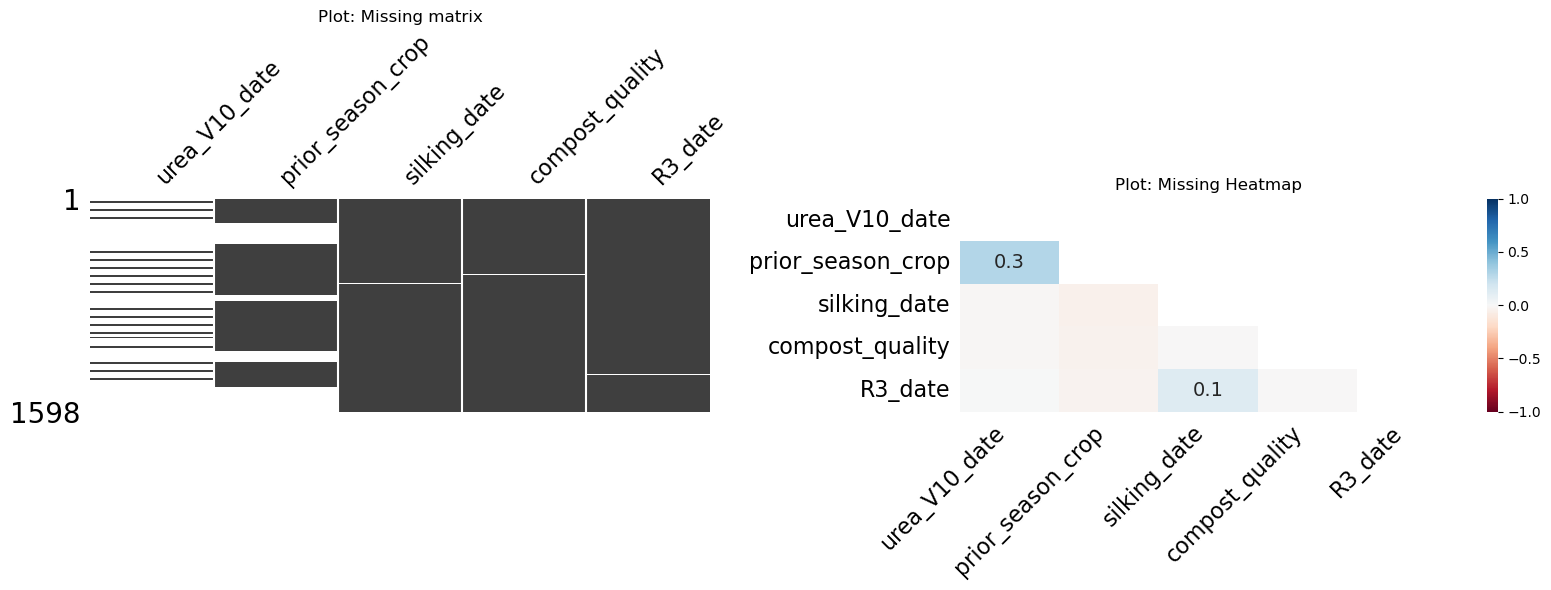



Soil


tot_N    100.000000
sand     100.000000
org_C    100.000000
pH         0.271739
dtype: float64

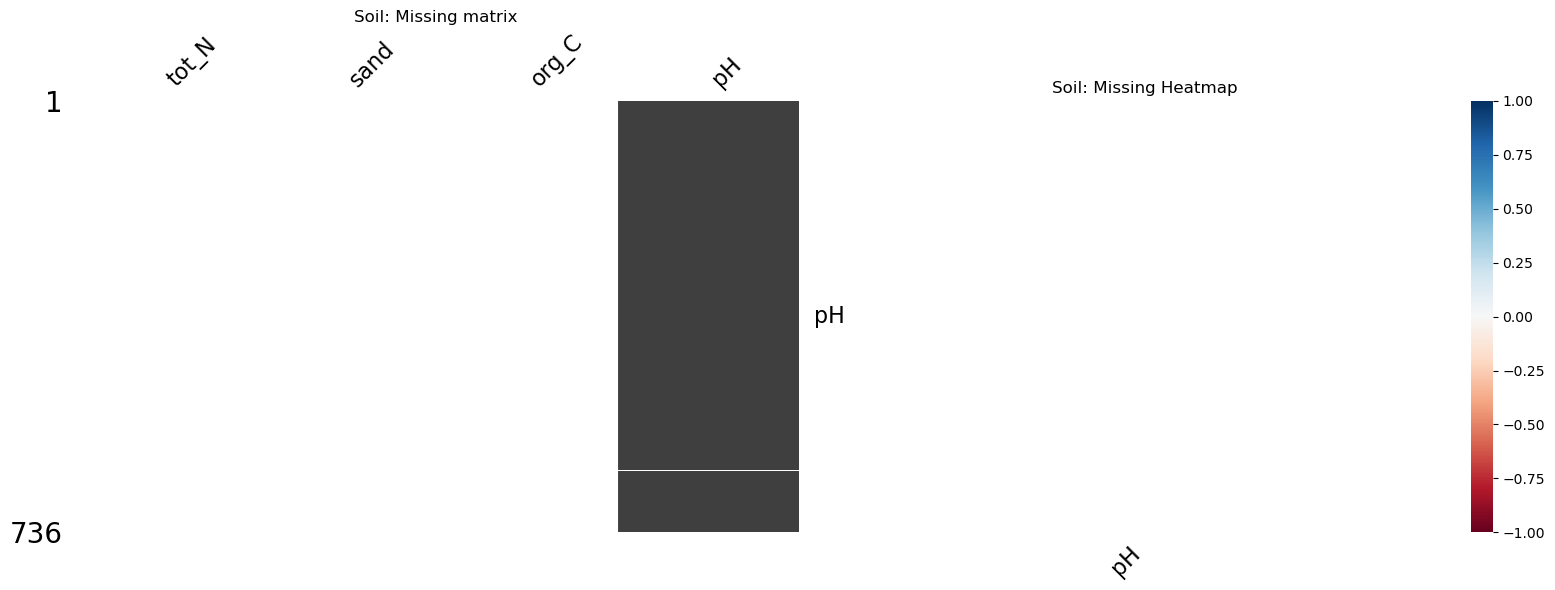

In [25]:
import missingno as msno
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

for name,df in datasets.items():
    
    missing = (df.isnull().sum()/len(df))*100
    missing = missing.sort_values(ascending=False)
    
    print("\n")
    print(name)
    
    missing_var = missing[missing > 0]
    display(missing_var)
    if len(missing_var) > 0:
        subset_df = df[missing_var.index]
        fig, ax = plt.subplots(
            nrows = 1,
            ncols = 2,
            figsize = (16,6)
        )
        msno.matrix(subset_df,ax = ax[0])
        ax[0].set_title(f"{name}: Missing matrix")
        
        msno.heatmap(subset_df,ax = ax[1])
        ax[1].set_title(f"{name}: Missing Heatmap")
        plt.tight_layout()
        plt.show()    
       

## Investigating Missingness Patterns

We want to investigate whether missingness is distributed differently across observed characteristics, particularly mega-environment. 

- This should provide evidence about the pattern and potential systematic nature of missingness but does not, by itself, establish whether the data are MCAR, MAR or MNAR.

### Missingness in Field Data Frame

In [26]:
field_missing_vars = ['trialfield_home_min','slope_pos','soil_depth','rockness',
                'cult_land','trial_follower_gender']

In [27]:
for var in field_missing_vars:
    
    # Creating missing indicator
    field_df[f'{var}_missing'] = field_df[var].isnull()
    
    print(f"\n{'='*50}")
    print(f"missingness Pattern for: {var}")
    print(f"{'='*50}")
    
    output = (
        field_df.groupby(f'{var}_missing')['meg_env']
        .value_counts(dropna = False)
    )
    print(output)


missingness Pattern for: trialfield_home_min
trialfield_home_min_missing  meg_env     
False                        Low-Mid-Dry      45
                             Highlands        35
                             Low-Mid-Wet      24
                             Transitional     14
True                         Highlands       107
                             Low-Mid-Dry      70
                             Low-Mid-Wet      53
                             Transitional     51
Name: count, dtype: int64

missingness Pattern for: slope_pos
slope_pos_missing  meg_env     
False              Low-Mid-Dry     85
                   Highlands       70
                   Low-Mid-Wet     59
                   Transitional    28
True               Highlands       72
                   Transitional    37
                   Low-Mid-Dry     30
                   Low-Mid-Wet     18
Name: count, dtype: int64

missingness Pattern for: soil_depth
soil_depth_missing  meg_env     
False               Low-Mi

The output above shows missingness by mega environment.

for instance, in terms of field position on hill:

-  72 records in highland mega environment are missing, and
 
-  37 records in transitional mega environments are missing

The above findings can further be represented in a more friendlier manner using plots as below.

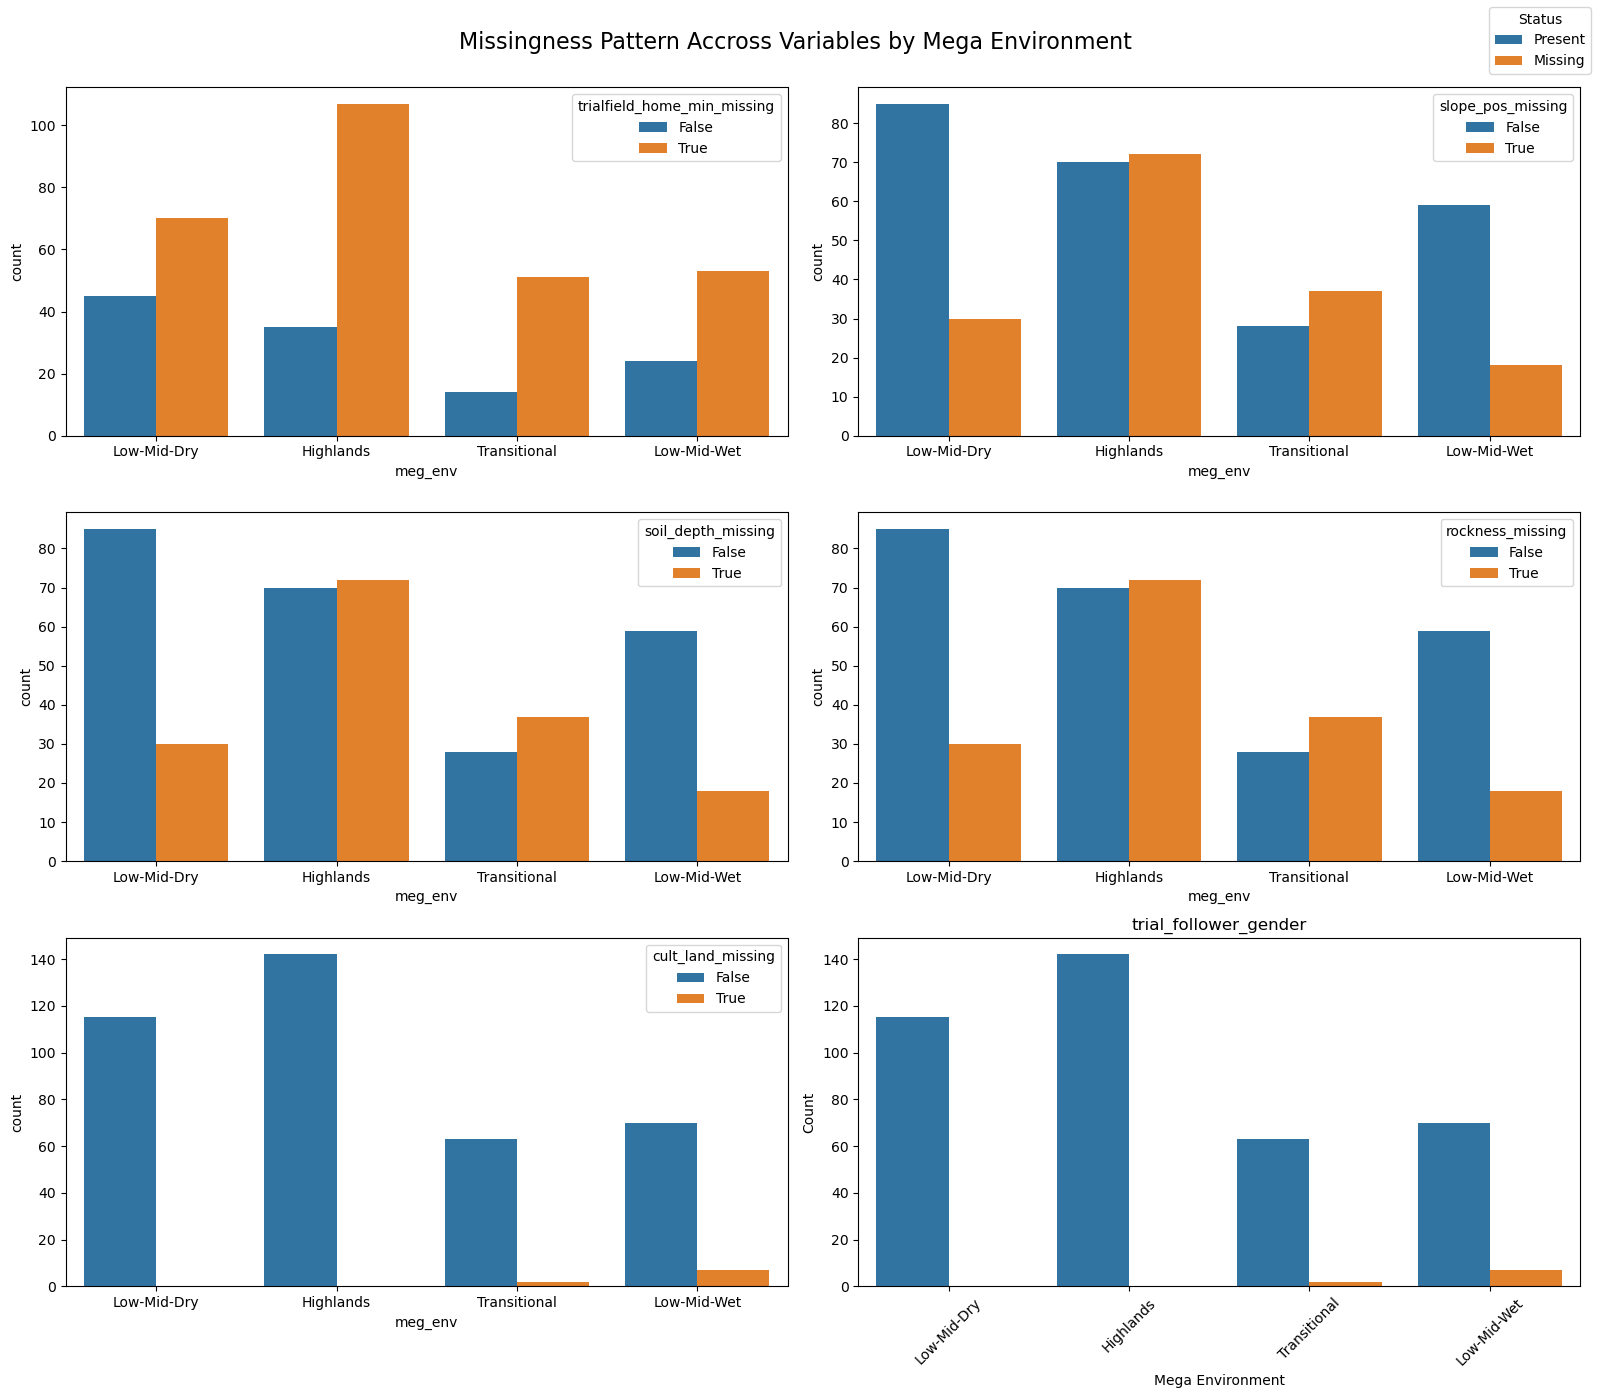

In [28]:
import seaborn as sns

# Create a grid
fig, axes = plt.subplots(
    nrows = 3,
    ncols = 2,
    figsize = (16,14)
)
axes = axes.flatten()
for i, var in enumerate(field_missing_vars):
    # Missingness indicator
    field_df[f'{var}_missing'] = field_df[var].isnull()
    
    sns.countplot(
        data = field_df,
        x = 'meg_env',
        hue = f'{var}_missing',
        ax = axes[i]
)
axes[i].set_title(f'{var}')
axes[i].set_xlabel('Mega Environment')
axes[i].set_ylabel('Count')
axes[i].tick_params(axis = 'x', rotation = 45)

# Remove individual legends
axes[i].legend_.remove()

# Create one share legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    ['Present','Missing'],
    title = 'Status',
    loc = 'upper right'
)

plt.suptitle(
    'Missingness Pattern Accross Variables by Mega Environment',
    fontsize = 16
)

plt.tight_layout()
plt.subplots_adjust(top = 0.94)
plt.show()

The above column plots indicate a comparison of missing data by mega environment.

For instance, it illustrates that data on time from farmers' homes to the respective trial fields had the most data missing across all four mega environments. 
- On the same note, Highlands can be seen to have the largest number of missing observations for `trialfield_home_min`. 
- However, since the mega-environments may differ in sample size, missingness rates should be compared before concluding that missingness is disproportionately concentrated in Highlands.

The plots also illustrate that visual pebble content in trial fields was significantly missing across mega environments, especially in highland mega environments.

### Missingness in Plot Data Frame

For the Plot dataframe, since we don't have the Mega Environment as part of the dataframe, we'll need to create the smallest possible merge of the datasets, albeit temporarily, to investigate why missingness occurs.

In [29]:

plot_audit = plot_df.merge(
    field_df[
        ['block_id','meg_env']
    ],
    on = 'block_id',
    how = 'left'
)

In [30]:
plot_missing_vars = ['urea_V10_date','prior_season_crop','silking_date',
                     'compost_quality','R3_date']

In [31]:
for var in plot_missing_vars:
    
    # Creating missing indicator
    plot_audit[f'{var}_missing'] = plot_audit[var].isnull()
    
    print(f"\n{'='*50}")
    print(f"missingness Pattern for: {var}")
    print(f"{'='*50}")
    
    output = (
        plot_audit.groupby(f'{var}_missing')['meg_env']
        .value_counts(dropna = False)
    )
    print(output)


missingness Pattern for: urea_V10_date
urea_V10_date_missing  meg_env     
False                  Highlands       107
                       Low-Mid-Dry      75
                       Transitional     53
                       Low-Mid-Wet      49
                       NaN               2
True                   Highlands       458
                       Low-Mid-Dry     385
                       Low-Mid-Wet     259
                       Transitional    207
                       NaN               3
Name: count, dtype: int64

missingness Pattern for: prior_season_crop
prior_season_crop_missing  meg_env     
False                      Highlands       425
                           Low-Mid-Dry     300
                           Transitional    212
                           Low-Mid-Wet     196
                           NaN               5
True                       Low-Mid-Dry     160
                           Highlands       140
                           Low-Mid-Wet     112
        

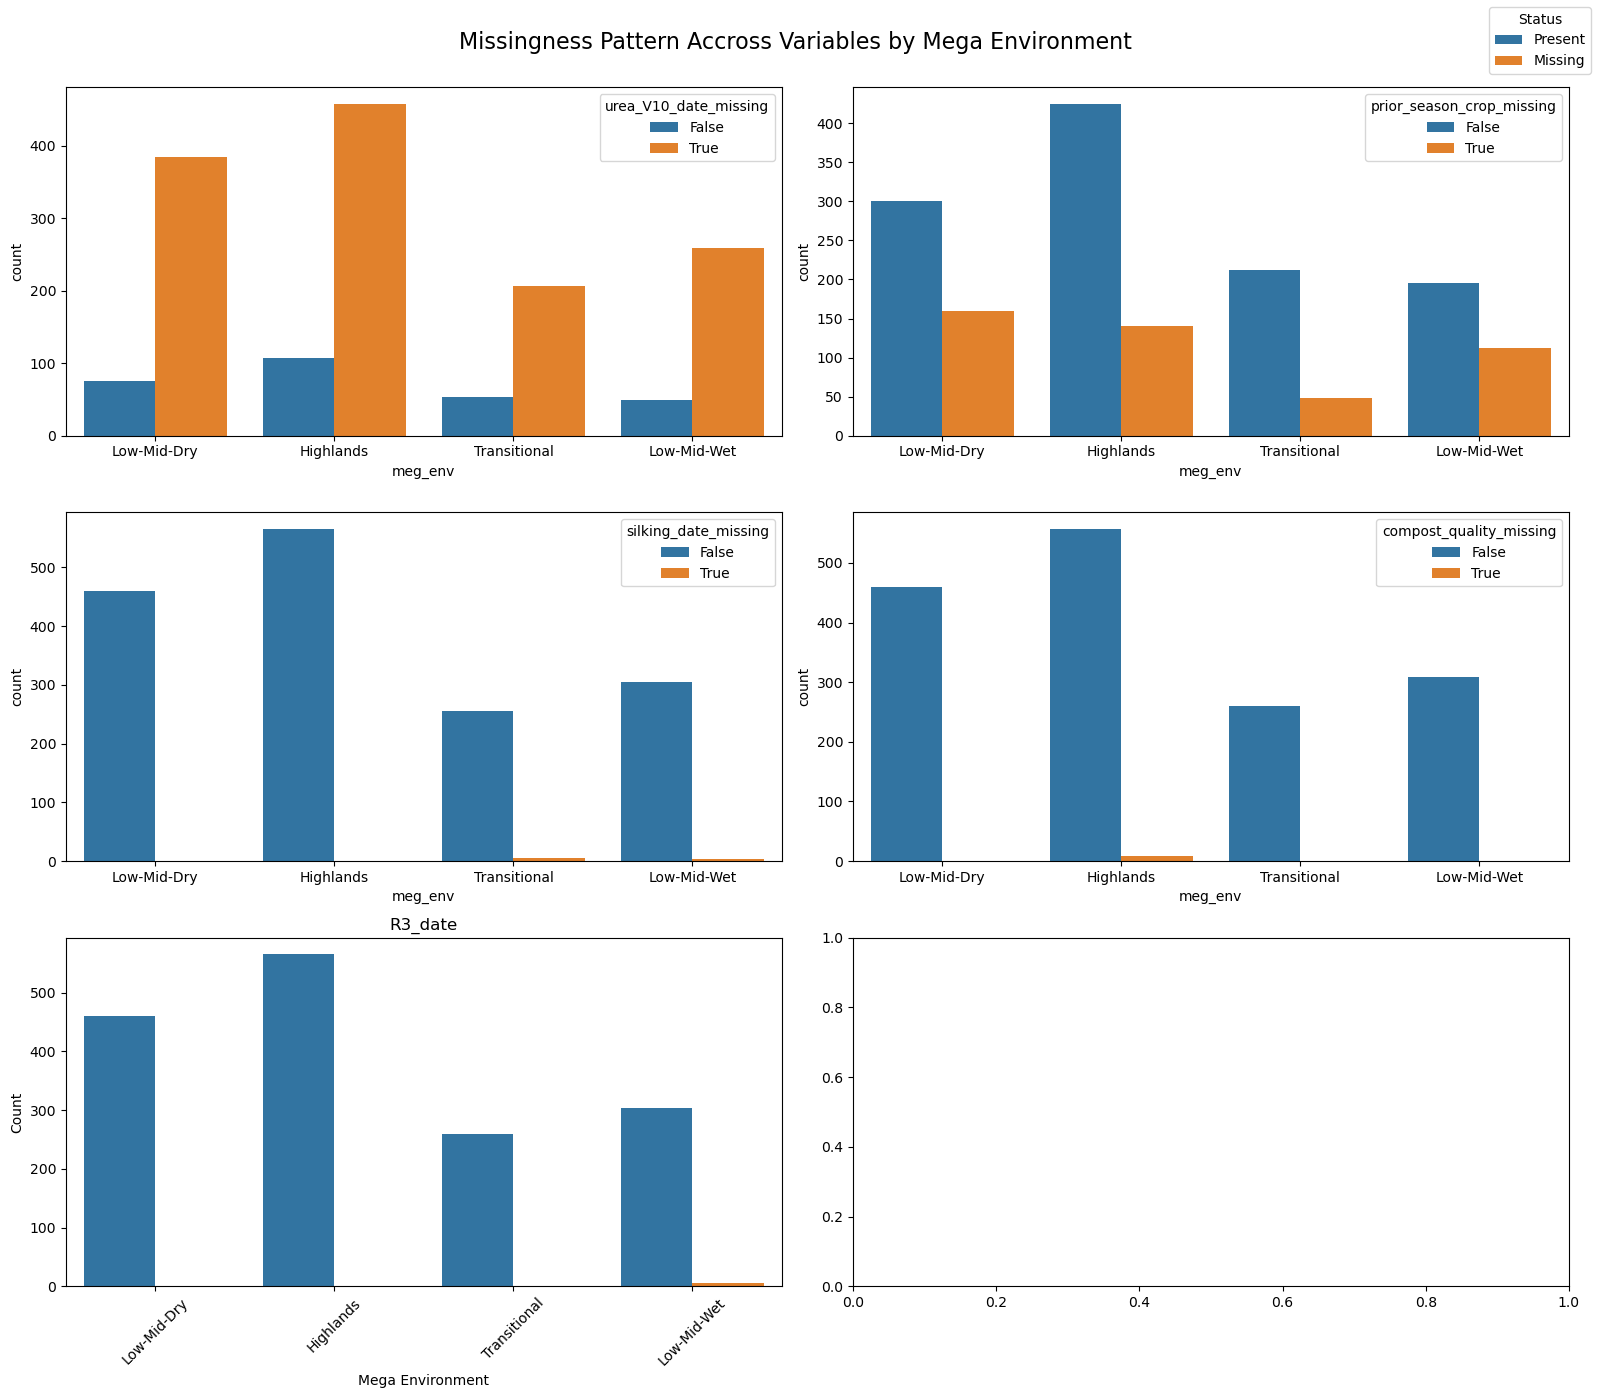

In [32]:
# Create a grid
fig, axes = plt.subplots(
    nrows = 3,
    ncols = 2,
    figsize = (16,14)
)
axes = axes.flatten()
for i, var in enumerate(plot_missing_vars):
    # Missingness indicator
    plot_audit[f'{var}_missing'] = plot_audit[var].isnull()
    
    sns.countplot(
        data = plot_audit,
        x = 'meg_env',
        hue = f'{var}_missing',
        ax = axes[i]
)
axes[i].set_title(f'{var}')
axes[i].set_xlabel('Mega Environment')
axes[i].set_ylabel('Count')
axes[i].tick_params(axis = 'x', rotation = 45)

# Remove individual legends
axes[i].legend_.remove()

# Create one share legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    ['Present','Missing'],
    title = 'Status',
    loc = 'upper right'
)

plt.suptitle(
    'Missingness Pattern Accross Variables by Mega Environment',
    fontsize = 16
)

plt.tight_layout()
plt.subplots_adjust(top = 0.94)
plt.show()

### Missingness in Soil Data Frame

Similarly, For the soil dataframe, since we only have the `plot_id` but no `block_id` or `meg_env` as variables, we'll have to perform a temporary merge so we can be able to investigate missingness by meg_env. 

For this, we'll need to merge the soil_df to the temporary plot_audit dataframe.

In [33]:
soil_audit = soil_df.merge(
    plot_audit[
        ['plot_id','meg_env']
    ],
    on = 'plot_id',
    how = 'left'
)

In [34]:
soil_missing_vars = ['tot_N','sand','org_C','pH']

In [35]:
for var in soil_missing_vars:
    
    # Creating missing indicator
    soil_audit[f'{var}_missing'] = soil_audit[var].isnull()
    
    print(f"\n{'='*50}")
    print(f"missingness Pattern for: {var}")
    print(f"{'='*50}")
    
    output = (
        soil_audit.groupby(f'{var}_missing')['meg_env']
        .value_counts(dropna = False)
    )
    print(output)


missingness Pattern for: tot_N
tot_N_missing  meg_env     
True           Highlands       242
               Low-Mid-Dry     232
               Low-Mid-Wet     160
               Transitional    100
               NaN               2
Name: count, dtype: int64

missingness Pattern for: sand
sand_missing  meg_env     
True          Highlands       242
              Low-Mid-Dry     232
              Low-Mid-Wet     160
              Transitional    100
              NaN               2
Name: count, dtype: int64

missingness Pattern for: org_C
org_C_missing  meg_env     
True           Highlands       242
               Low-Mid-Dry     232
               Low-Mid-Wet     160
               Transitional    100
               NaN               2
Name: count, dtype: int64

missingness Pattern for: pH
pH_missing  meg_env     
False       Highlands       241
            Low-Mid-Dry     232
            Low-Mid-Wet     159
            Transitional    100
            NaN               2
True      

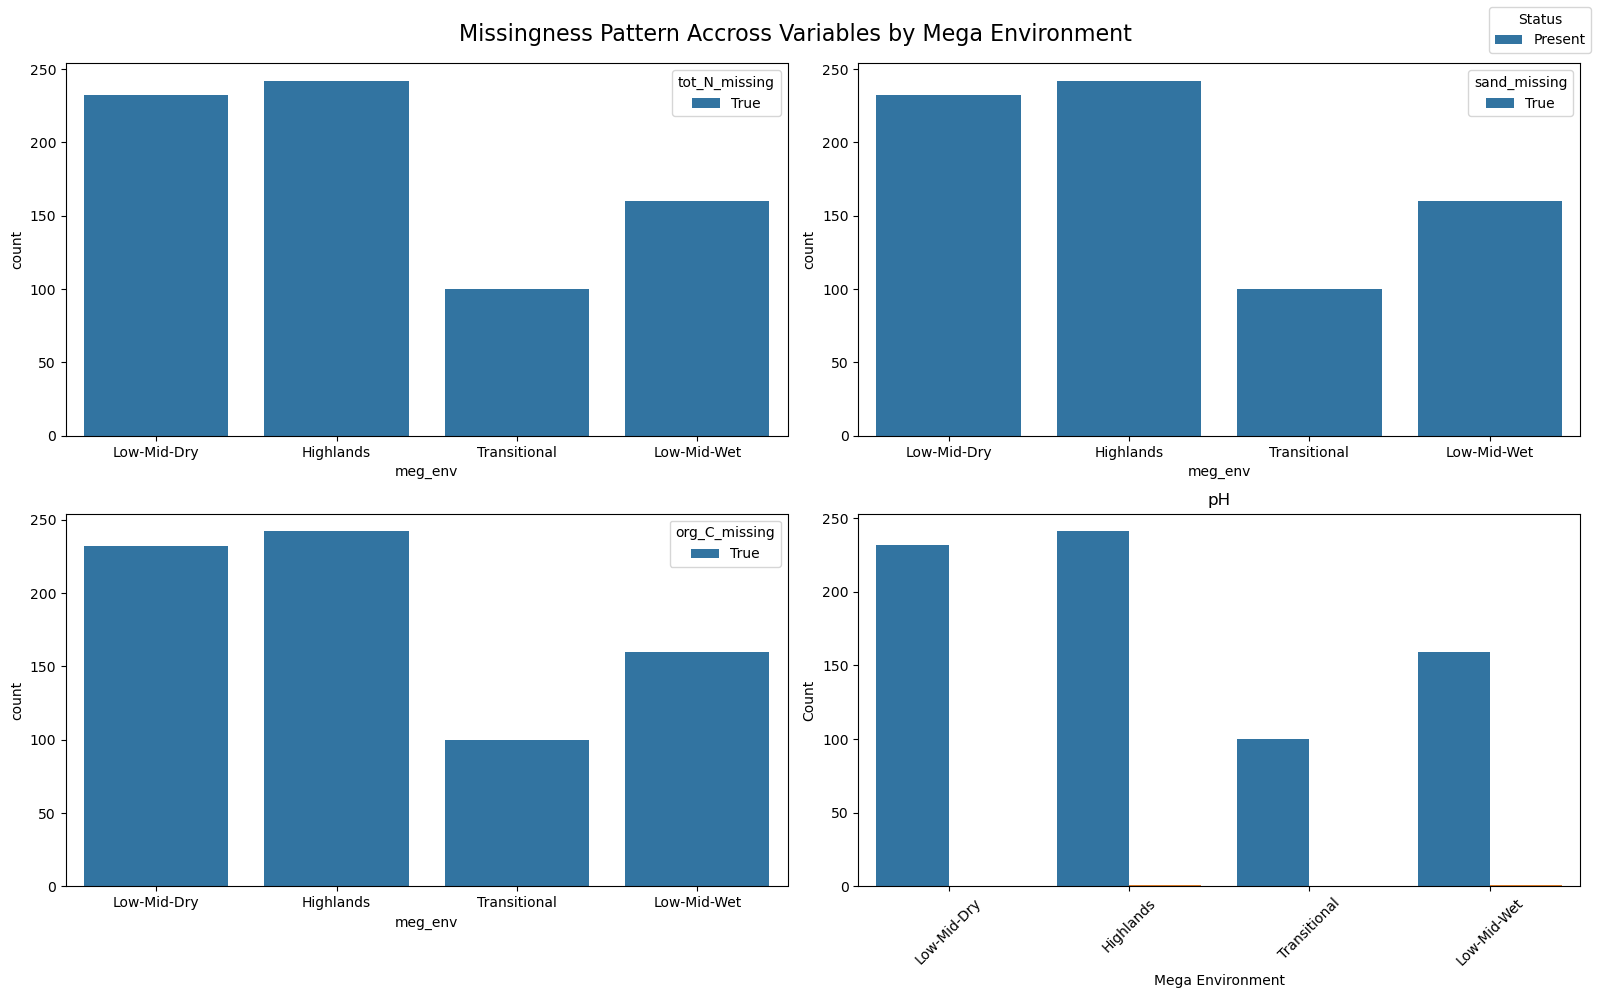

In [36]:
# Create a grid
fig, axes = plt.subplots(
    nrows = 2,
    ncols = 2,
    figsize = (16,10)
)
axes = axes.flatten()
for i, var in enumerate(soil_missing_vars):
    # Missingness indicator
    soil_audit[f'{var}_missing'] = soil_audit[var].isnull()
    
    sns.countplot(
        data = soil_audit,
        x = 'meg_env',
        hue = f'{var}_missing',
        ax = axes[i]
)
axes[i].set_title(f'{var}')
axes[i].set_xlabel('Mega Environment')
axes[i].set_ylabel('Count')
axes[i].tick_params(axis = 'x', rotation = 45)

# Remove individual legends
axes[i].legend_.remove()

# Create one share legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    ['Present','Missing'],
    title = 'Status',
    loc = 'upper right'
)

plt.suptitle(
    'Missingness Pattern Accross Variables by Mega Environment',
    fontsize = 16
)

plt.tight_layout()
plt.subplots_adjust(top = 0.94)
plt.show()

## Duplicate Analysis

In this section, we are interested in flagging complete duplicate records. This should give insight into whether, for example, there were repeated measurements. 

In [37]:
for name, df in datasets.items():
    
    print(
        f"{name}:",
        df.duplicated().sum()
    )

Field: 0
Plot: 0
Soil: 0


## Identifier integrity check

In [38]:
field_df['block_id'].nunique()

399

In [39]:
plot_df['plot_id'].nunique()

1598

In [40]:
plot_counts = plot_audit.groupby(
    'block_id'
).size()

plot_counts.value_counts()

4    396
3      4
2      1
Name: count, dtype: int64

In [41]:
soil_df['plot_id'].nunique()

736

## Plugging Audit Gaps

With our audit results, it's evident there are some glaring audit gaps

It'll help by a lot if we could plug these gaps before identifying how to proceed with cleaning

### Check 1: Identifying incomplete field-season units

We want to identify the five incomplete field-season units identified in the audit exercise above

In [42]:
field_plot_counts = (
    plot_df
    .groupby(["block_id", "season"])
    .agg(
        n_plots=("plot_id", "nunique"),
        n_treatments=("urea_rate_timing", "nunique")
    )
    .reset_index()
)

field_plot_counts[field_plot_counts["n_plots"] < 4]

,block_id,season,n_plots,n_treatments
12,0c966b09-83f7-4587-8e2c-54fc51e41ee0,21A,3,3
87,4612f63d-b7a0-4cd9-af8a-2929f320c128,21A,3,3
187,8330dae5-352b-4729-9dc9-3a21c6596b20,22A,3,3
211,8eca62d8-71d0-4e04-a92b-51118e53a6c5,22B,2,2
299,c58890fb-e313-42f7-8f59-d64c28019ee1,21A,3,3


We can now establish that:
- 396 / 401 = 98.75% of field-season units have four plots
- 5 / 401 = 1.25% are incomplete
- Four units are missing one plot, and 
- One unit is missing two plots.
This is reassuring from an experimental structure perspective, implying the trial was overwhelmingly consistent with the stated four-plot design.

However, it's still important to establish which treatment(s) are missing from each incomplete field-season before we can decide how the five units may affect analysis

In [43]:
field_plot_counts[field_plot_counts["n_treatments"] < 4]

,block_id,season,n_plots,n_treatments
12,0c966b09-83f7-4587-8e2c-54fc51e41ee0,21A,3,3
87,4612f63d-b7a0-4cd9-af8a-2929f320c128,21A,3,3
187,8330dae5-352b-4729-9dc9-3a21c6596b20,22A,3,3
211,8eca62d8-71d0-4e04-a92b-51118e53a6c5,22B,2,2
299,c58890fb-e313-42f7-8f59-d64c28019ee1,21A,3,3


While we want to identify exactly which treatments are missing, this check does not actually achieve that, but we can still identify the incomplete units. 

`n_treatments = 3` only tells us that three distinct treatments are present.

Overall, the first 2 checks tell us that:

Of the 401 field-season units represented in Plot_Level:
- 396 (98.75%) contain four plots and four distinct Urea treatments, while five (1.25%) are incomplete. 
- Four field-season units contain three plots/treatments and one contains two. 

The incomplete units require further investigation to determine which treatment(s) are absent and whether the absence reflects experimental implementation or missing data.

Now let's explicitly identify the missing treatment

In [44]:
expected_treatments = set(
    plot_df["urea_rate_timing"].dropna().unique()
)

def missing_treatments(group):
    observed = set(group["urea_rate_timing"].dropna())
    return expected_treatments - observed

incomplete_treatments = (
    plot_df
    .groupby(["block_id", "season"])
    .apply(missing_treatments)
)

incomplete_treatments[
    incomplete_treatments.apply(len) > 0
]

block_id                              season
0c966b09-83f7-4587-8e2c-54fc51e41ee0  21A                                 {Urea 0.5Kg/Are(V6)}
4612f63d-b7a0-4cd9-af8a-2929f320c128  21A                           {Urea1kg/Are(Planting+V6)}
8330dae5-352b-4729-9dc9-3a21c6596b20  22A                           {Urea1kg/Are(Planting+V6)}
8eca62d8-71d0-4e04-a92b-51118e53a6c5  22B       {Urea1kg/Are(Planting+V6), Urea 0.5Kg/Are(V6)}
c58890fb-e313-42f7-8f59-d64c28019ee1  21A                           {Urea1kg/Are(Planting+V6)}
dtype: object

### Check 2: Investigating Soil coverage

In [45]:
soil_df["plot_id"].nunique()

736

In [46]:
soil_df["plot_id"].duplicated().sum()

np.int64(0)

The absence of duplicate `plot_id`s is good. It implies that, within Soil_PL each plot has at most one soil record.

But ned to establish how much of the 1,598 Plot_Level population is represented.

By calculation:

$$ \frac{736}{1598}\times100 \approx 46.1\% $$

Only approximately 46.1% of plot observations have a Soil_PL record, assuming all 736 soil IDs correspond to plots in Plot_Level.

Consequently, approximately 53.9% of the plots are not represented in Soil_PL.

- This is a significant coverage issue.

But we need to also distinguish whether Soil_PL contains 736 plots that are also in Plot_Level?

- We need to establish whether Soil_PL contains 736 unique IDs, some of which don't even exist in Plot_Level?

So our next audit needs to establish the referential integrity between Plot_Level and Soil_PL.

Conceptually:
```
Plot_Level
1,598 plots
      │
      ├── 736 have soil records
      │
      └── 862 have no soil record
```

But we need to verify those numbers rather than assume them as it will matter later if:

- Suppose we enrich the dataset with SoilGrids, we need to decide whether SoilGrids should be used to
            
      - fill the 3 completely empty soil variables for the 736 existing soil records;
      - provide soil information for the 862 plots with no Soil_PL record;
      - potentially supplement all plots consistently.

That's a methodological decision we'll make later. Now let's establish how many Soil_PL records actually match Plot_Level.

In [47]:
soil_plot_check = soil_df[["plot_id"]].merge(
    plot_df[["plot_id"]].drop_duplicates(),
    on="plot_id",
    how="left",
    indicator=True
)

soil_plot_check["_merge"].value_counts()

_merge
both          736
left_only       0
right_only      0
Name: count, dtype: int64

Now the reverse

In [48]:
plot_soil_check = plot_df[["plot_id"]].drop_duplicates().merge(
    soil_df[["plot_id"]],
    on="plot_id",
    how="left",
    indicator=True
)

plot_soil_check["_merge"].value_counts()

_merge
left_only     862
both          736
right_only      0
Name: count, dtype: int64

### Check 3: Investigating whether `urea_V10_Date` missingness is structural

In [49]:
plot_df.groupby(
    "urea_rate_timing"
)["urea_V10_date"].apply(
    lambda x: x.isna().sum()
)

urea_rate_timing
Urea 0.5Kg/Are(V6)          399
Urea 1kg/Are(V6 + V10)      115
Urea 1kg/Are(V6)            401
Urea1kg/Are(Planting+V6)    397
Name: urea_V10_date, dtype: int64

In [50]:
plot_df.groupby(
    "urea_rate_timing"
)["urea_V10_date"].apply(
    lambda x: x.notna().sum()
)

urea_rate_timing
Urea 0.5Kg/Are(V6)            0
Urea 1kg/Are(V6 + V10)      286
Urea 1kg/Are(V6)              0
Urea1kg/Are(Planting+V6)      0
Name: urea_V10_date, dtype: int64

We have Total:

- Missing = 1,312
- Non-missing = 286

So the overall missingness is:

$$ 1312/1598 = 82.1\% $$

This may look terrible at first glance. But the more important question is why exactly do most of it occur?

The research establishes that only Urea 1kg/Are(V6 + V10) should have a V10 application.

And indeed:

- all 399 observations in the 0.5 kg/Are V6 treatment have no V10 date;
- all 401 observations in the 1 kg/Are V6 treatment have no V10 date;
- all 397 observations in the Planting + V6 treatment have no V10 date.

Those three treatments account for:

$$ 399+401+397=1197 $$

plots. So 1,197 of the 1,312 missing V10 dates are structurally expected. That's 91.2% of the missing V10 dates; **a very useful finding.**

But we still have a genuine issue inside the V6 + V10 treatment. V6 + V10 treatment has
```
401 total observations
286 non-missing V10 dates
115 missing V10 dates
```
Therefore:

$$ 115/401 \approx 28.7\% $$

of the plots assigned to the V6 + V10 treatment are missing a V10 date.

This is not explained by treatment structure, so is the part we need to investigate.

There are at least two possibilities:

- Possibility A — V10 was actually applied but the date wasn't recorded

    - Then we have a data-recording missingness problem.

- Possibility B — V10 was not actually applied to those plots

    - Then we potentially have an experimental implementation/compliance issue.

Those are very different.

We should therefore not impute the missing dates at this point. Instead, we need to investigate the other V10-related variables:
- `urea_V10_kgha`
- `urea_total_kgha`
- `perhaps N_kgha`
- potentially `urea_rate_timing`

This could tell us whether those 115 plots received V10 Urea despite lacking a date, and gives us an important audit distinction.

We can now classify missingness more intelligently:

Structural / not applicable

For:

- Urea 0.5 kg/Are (V6)
- Urea 1 kg/Are (V6)
- Urea 1 kg/Are (Planting + V6)

`urea_V10_date` is expected to be missing. We should not impute these values.

Potentially problematic missingness

For:

- Urea 1 kg/Are (V6 + V10)

the 115 missing V10 dates require investigation. This distinction will become very important later when we prepare the data.

For now, we investigate the 115 missing V10 dates

In [51]:
v6_v10 = plot_df[
    plot_df["urea_rate_timing"] == "Urea 1kg/Are(V6 + V10)"
]

v6_v10[
    ["urea_V10_date", "urea_V10_kgha",
     "urea_total_kgha", "N_kgha"]
].isna().sum()

urea_V10_date      115
urea_V10_kgha        0
urea_total_kgha      0
N_kgha               0
dtype: int64

Now we inspect the values of `urea_V10_kgha` for the 115 observations

In [52]:
v6_v10[
    v6_v10["urea_V10_date"].isna()
]["urea_V10_kgha"].value_counts(dropna=False)

urea_V10_kgha
50    79
52    20
51    10
53     3
49     2
56     1
Name: count, dtype: int64

We find that all 115 observations have non-missing `urea_V10_kgha` value.
-  Meaning V10 Urea quantity was recorded for all 115 onservations despite the V10 application date not being rcorded. 

# Audit Summary

|Audit area	|Finding	|Interpretation / implication	|Status|
|----|----|----|----|
|Dataset inventory	|399 field, 1,598 plot and 736 soil records	|Establishes available data scale	|Complete|
|Field grain	|`block_id` unique across 399 Field records	|Field observations are uniquely identified within Field_Level	|Complete|
|Plot grain	|No duplicate (block_id, season, plot_id)	|Plot observations are uniquely identified	|Complete|
|Field–plot structure	|396/401 field-season units have 4 plots; 5 are incomplete	|Five experimental units require investigation	|Action required|
|Treatment structure	|Four treatment categories identified	|Treatment variable is available for comparative analysis	|Complete|
|Treatment allocation	|Five field-season units lack one or more expected treatments	|Specific treatment gaps require investigation	|Action required|
|Field–plot referential integrity	|Plot audit contains observations without matched field information	|Relationship between Field_Level and Plot_Level requires validation	|Action required|
|Soil referential integrity	|All 736 Soil_PL IDs match Plot_Level	|Soil records are valid, but incomplete in coverage	|Complete|
|Soil coverage	|736/1,598 plots = 46.1%	|862 plots have no Soil_PL record	|Action required|
|Soil variables	|`tot_N`, `org_C`, `sand` 100% missing	|These variables cannot currently be analyzed without additional information	|Action required|
|Soil pH	|2 missing values	|Very limited missingness	|Low priority|
|Field missingness	|Several variables have 39–70% missingness	|Missingness requires pattern/rate assessment	|Action required|
|Plot missingness	|`prior_season_crop` 28.8% missing	|Requires investigation of whether missingness is structural	|Action required|
|V10 date	|82.1% missing overall, largely structural	|Overall percentage is misleading; 28.7% missing within V6+V10 treatment is the substantive issue	|Action required|
|Date variables	|Several date fields stored as strings	|Require validation and conversion during preparation	|Action required|
|Complete duplicates	|No complete duplicate rows identified	|No immediate duplicate-row concern	|Complete|

## Issues Requiring Investigation

#### High priority

1. Field–Plot referential integrity

    - Why do some Plot_Level observations lack corresponding Field_Level information?
    - Are the five NaN mega-environment observations related to unmatched field records?

2. Incomplete experimental units

    - Identify the missing plots/treatments.
        - Determine whether they reflect actual experimental implementation or missing records.

3. V6 + V10 treatment

    - 115/401 observations lack a V10 date.
    - V10 quantities are nevertheless recorded.
        - Determine whether this is a recording issue or implementation issue.

4. Soil coverage

    - 862/1,598 plots lack Soil_PL records.
    - Determine whether external enrichment is appropriate.

#### Medium priority

5. Completely empty soil variables

    `tot_N`, `org_C`, `sand`.

6. Substantial field missingness

    `trialfield_home_min`, `slope_pos`, `rockness` and `soil_depth`

7. prior_season_crop

    28.8% missing.

#### Lower priority

8. Date-type conversion

    Important for preparation, but not a structural failure.

9. Two missing pH observations

    Very limited issue.


<h2 align = "center">
Phase 2: Data Quality Investigation & Validation
</h2>

We want to investigate the findings in the following order:

##### High priority
1. Field–Plot referential integrity
2. Incomplete field-season experimental units
3. Missing treatments
4. V6 + V10 treatment inconsistency
5. Soil coverage
##### Medium priority
6. Field-level missingness
7. prior_season_crop
8. Completely missing soil variables
##### Lower priority
9. Date variables
10. Missing pH

## 1st Investigation: Field-Plot referential integrity

We've found that plot observations exist without corresponding Field_Level information. Therefore, we need to determine **exactly which records are unmatched**

#### Stpe 1 - Identifying unmatched field-season combinations
We've already established that fields are identified by `block_id` and plots contain both `block_id` and `season`

We wnt to start by creating unique field combinations in each dataset

In [53]:
field_keys = (
    field_df[["block_id", "season"]]
    .drop_duplicates()
)

plot_keys = (
    plot_df[["block_id", "season"]]
    .drop_duplicates()
)

#### Step 2: Identifying plot combinations that don't exist in the field dataset

In [54]:
unmatched_plot_fields = (
    plot_keys
    .merge(
        field_keys,
        on=["block_id", "season"],
        how="left",
        indicator=True
    )
)

unmatched_plot_fields = unmatched_plot_fields[
    unmatched_plot_fields["_merge"] == "left_only"
]

unmatched_plot_fields

,block_id,season,_merge
260,8eca62d8-71d0-4e04-a92b-51118e53a6c5,22B,left_only
273,0c966b09-83f7-4587-8e2c-54fc51e41ee0,21A,left_only


We can see there are two unmatched combinations. But we want to determine whether the problem is `block-id` or `season` or both

We know that unmatched combinations can be as a result of one of the following reasons:

- **Scenario A:** the `block_id`may not be existing in Field_Level at all 

- **Scenario B:** the `block_id` may exist but the season may differ

- **Scenario C:** the block may exist but one of the values may have been formatted differently

- **Scenario D:** The plot record may genuinely be having no field-level record

But we have to be certain though.

In [55]:
plot_blocks = set(plot_df["block_id"].dropna())
field_blocks = set(field_df["block_id"].dropna())

unmatched_blocks = plot_blocks - field_blocks

len(unmatched_blocks), unmatched_blocks

(2,
 {'0c966b09-83f7-4587-8e2c-54fc51e41ee0',
  '8eca62d8-71d0-4e04-a92b-51118e53a6c5'})

We see there are 2 unmatched field-season combinations in Plot_Level.

#### Step 3: Inspecting the seasons associated with the identified blocks

In [56]:
plot_df[
    plot_df["block_id"].isin(unmatched_blocks)
][["block_id", "season"]].drop_duplicates()

,block_id,season
1039,8eca62d8-71d0-4e04-a92b-51118e53a6c5,22B
1089,0c966b09-83f7-4587-8e2c-54fc51e41ee0,21A


Both block_id values are absent from Field_Level, meaning they are not merely associated with a different season

The corresponding plots therefore, lack their expected field-level context, including mega-environment, agro-ecological zone and field characteristics

This is a genuine referential-integrity issue:
- The two field-seaon units cannot be assigned field-level characteristics through the existing field table

- We, however, cannot establish yet whether the cause is an omitted field record, an identifier problem, or another source-data issue.

We'll need therefore to preserve the two unmatched plot groups while investigating their origin 
- We don't want to delete the plots automatically, or invent field attributes for them

### 2nd Investigation - Incomplete experimental units

We found 396/401 field-season units have four plots 
- This is essential as the experimental design indicated that each field was subdivided into four plots 

We want to identify the five not conforming to the design

In [58]:
plot_counts = (
    plot_df.groupby(["block_id", "season"])
        .agg(
            n_plots=("plot_id", "nunique")
        )
        .reset_index()
)

incomplete_fields = plot_counts[
    plot_counts["n_plots"] != 4
]

incomplete_fields

,block_id,season,n_plots
12,0c966b09-83f7-4587-8e2c-54fc51e41ee0,21A,3
87,4612f63d-b7a0-4cd9-af8a-2929f320c128,21A,3
187,8330dae5-352b-4729-9dc9-3a21c6596b20,22A,3
211,8eca62d8-71d0-4e04-a92b-51118e53a6c5,22B,2
299,c58890fb-e313-42f7-8f59-d64c28019ee1,21A,3


We are not just going to stop at numbers. We watn to inspect exactly what is missing

In [59]:
for _, row in incomplete_fields.iterrows():
    
    print(
        "\nBlock:", row["block_id"],
        "| Season:", row["season"],
        "| Number of plots:", row["n_plots"]
    )
    
    display(
        plot_df[
            (plot_df["block_id"] == row["block_id"]) &
            (plot_df["season"] == row["season"])
        ][
            ["plot_id", "treat_code", "urea_rate_timing", "yield_tha"]
        ]
    )


Block: 0c966b09-83f7-4587-8e2c-54fc51e41ee0 | Season: 21A | Number of plots: 3


,plot_id,treat_code,urea_rate_timing,yield_tha
1089,0c966b09-83f7-4587-8e2c-54fc51e41ee0-21A-B,B,Urea1kg/Are(Planting+V6),3.71
1090,0c966b09-83f7-4587-8e2c-54fc51e41ee0-21A-C,C,Urea 1kg/Are(V6 + V10),4.83
1091,0c966b09-83f7-4587-8e2c-54fc51e41ee0-21A-D,D,Urea 1kg/Are(V6),4.54



Block: 4612f63d-b7a0-4cd9-af8a-2929f320c128 | Season: 21A | Number of plots: 3


,plot_id,treat_code,urea_rate_timing,yield_tha
1407,4612f63d-b7a0-4cd9-af8a-2929f320c128-21A-A,A,Urea 0.5Kg/Are(V6),2.77
1408,4612f63d-b7a0-4cd9-af8a-2929f320c128-21A-C,C,Urea 1kg/Are(V6 + V10),1.68
1409,4612f63d-b7a0-4cd9-af8a-2929f320c128-21A-D,D,Urea 1kg/Are(V6),4.23



Block: 8330dae5-352b-4729-9dc9-3a21c6596b20 | Season: 22A | Number of plots: 3


,plot_id,treat_code,urea_rate_timing,yield_tha
348,8330dae5-352b-4729-9dc9-3a21c6596b20-22A-A,A,Urea 0.5Kg/Are(V6),6.45
349,8330dae5-352b-4729-9dc9-3a21c6596b20-22A-C,C,Urea 1kg/Are(V6 + V10),8.97
350,8330dae5-352b-4729-9dc9-3a21c6596b20-22A-D,D,Urea 1kg/Are(V6),7.08



Block: 8eca62d8-71d0-4e04-a92b-51118e53a6c5 | Season: 22B | Number of plots: 2


,plot_id,treat_code,urea_rate_timing,yield_tha
1039,8eca62d8-71d0-4e04-a92b-51118e53a6c5-22B-C,C,Urea 1kg/Are(V6 + V10),2.40
1040,8eca62d8-71d0-4e04-a92b-51118e53a6c5-22B-D,D,Urea 1kg/Are(V6),1.92



Block: c58890fb-e313-42f7-8f59-d64c28019ee1 | Season: 21A | Number of plots: 3


,plot_id,treat_code,urea_rate_timing,yield_tha
1380,c58890fb-e313-42f7-8f59-d64c28019ee1-21A-A,A,Urea 0.5Kg/Are(V6),4.33
1381,c58890fb-e313-42f7-8f59-d64c28019ee1-21A-C,C,Urea 1kg/Are(V6 + V10),3.94
1382,c58890fb-e313-42f7-8f59-d64c28019ee1-21A-D,D,Urea 1kg/Are(V6),3.57


What we establish is that the overall structure is highly consistent with the four-plot design.
- but five units have incomplete treatment representation. 

This matters because the design is such that each field-season unit receives all four treatments. 

- Without all four, those units cannot provide a complete within-field comparison of every treatment.

We have, however, only establishes that the records are absent; we haven't established whether those plots:
- were never implemented, 
- failed in the field, or 
- were omitted during data collection or export.

We'll, therefore, retain the existing plot records provisionally, flag the five incomplete units, and avoid reconstructing missing plots or yields. For treatment analysis, we will account for incomplete units explicitly rather than assuming every field had all treatments

### 3rd Investigation - Missing Treatment Allocation

Here we want to identify which treatments are absent 

We first establish the four expected treatments

In [60]:
expected_treatments = set(
    plot_df["urea_rate_timing"].dropna().unique()
)

expected_treatments

{'Urea 0.5Kg/Are(V6)',
 'Urea 1kg/Are(V6 + V10)',
 'Urea 1kg/Are(V6)',
 'Urea1kg/Are(Planting+V6)'}

we then want to identify the treatments observed within each field-season combination

In [61]:
treatment_matrix = (
    plot_df.pivot_table(
        index = ["block_id","season"],
        columns = "urea_rate_timing",
        values = "plot_id",
        aggfunc = "count",
        fill_value = 0
    )
)

treatment_matrix

,urea_rate_timing,Urea 0.5Kg/Are(V6),Urea 1kg/Are(V6 + V10),Urea 1kg/Are(V6),Urea1kg/Are(Planting+V6)
block_id,season,,,,
014d6b73d08a42c1be8990d884b17206,22A,1,1,1,1
02a456dc-95f9-4e68-8187-f67031bcb563,21A,1,1,1,1
03acd043-8c5c-4f17-8806-df3b28ef6399,22A,1,1,1,1
0449f3bc-838b-4e0c-89f3-fe9f31111b08,22A,1,1,1,1
04964b51-dbf6-4685-a928-cbbeabb249c9,21A,1,1,1,1
...,...,...,...,...,...
fe36931b-2707-4cdf-8ce9-381301cb1deb,22B,1,1,1,1
fea0cb2354e64560af1626623e02b44b,22A,1,1,1,1
ff07ff1f-cc90-45ac-9020-bf5680503c06,22A,1,1,1,1


Now we can identify incomplete treatment allocation using

In [62]:
incomplete_treatment = treatment_matrix[
    (treatment_matrix == 0).any(axis=1)
]

incomplete_treatment

,urea_rate_timing,Urea 0.5Kg/Are(V6),Urea 1kg/Are(V6 + V10),Urea 1kg/Are(V6),Urea1kg/Are(Planting+V6)
block_id,season,,,,
0c966b09-83f7-4587-8e2c-54fc51e41ee0,21A,0,1,1,1
4612f63d-b7a0-4cd9-af8a-2929f320c128,21A,1,1,1,0
8330dae5-352b-4729-9dc9-3a21c6596b20,22A,1,1,1,0
8eca62d8-71d0-4e04-a92b-51118e53a6c5,22B,0,1,1,0
c58890fb-e313-42f7-8f59-d64c28019ee1,21A,1,1,1,0


### 4th Investigation - V6 + V10 treatment

We already found 115/401 observations in the V6 + V10 treatment lack a V10 date

- but we also found that the V10 quantities were nevertheless recorded 

So to answer our validation question, we want to first identify the treatment

In [63]:
v6_v10 = plot_df[
    plot_df["urea_rate_timing"]
    == "Urea 1kg/Are(V6 + V10)"
]

In [64]:
v6_v10[
    [
        "block_id",
        "season",
        "plot_id",
        "urea_V6_date",
        "urea_V6_kgha",
        "urea_V10_date",
        "urea_V10_kgha",
        "urea_total_kgha"
    ]
].head(20)

,block_id,season,plot_id,urea_V6_date,urea_V6_kgha,urea_V10_date,urea_V10_kgha,urea_total_kgha
2,adfa31ad-95bf-453d-94f1-d163a97756ee,21A,adfa31ad-95bf-453d-94f1-d163a97756ee-21A-C,11/11/2020,50,12/3/2020,50,100
6,d8807f25-e675-49ae-87a3-d228eca23c72,21A,d8807f25-e675-49ae-87a3-d228eca23c72-21A-C,11/11/2020,50,12/3/2020,50,99
10,262efa71-6ff4-4e18-b6f1-0c3d293504c0,21A,262efa71-6ff4-4e18-b6f1-0c3d293504c0-21A-C,11/5/2020,50,11/30/2020,50,100
14,95c016dd-908a-4f07-9e49-926e9a9f4f19,21A,95c016dd-908a-4f07-9e49-926e9a9f4f19-21A-C,11/5/2020,50,11/30/2020,50,100
18,1d5c61a0-ca6b-4db8-87c3-5ca46c7cad6d,21A,1d5c61a0-ca6b-4db8-87c3-5ca46c7cad6d-21A-C,11/11/2020,50,11/30/2020,50,99
22,6bbda1ad-cac0-405a-af23-1d7b92b9e8c2,21A,6bbda1ad-cac0-405a-af23-1d7b92b9e8c2-21A-C,11/11/2020,50,12/4/2020,50,100
26,975e5e46-7503-4d90-b32a-f33a234a1bd5,21A,975e5e46-7503-4d90-b32a-f33a234a1bd5-21A-C,11/11/2020,50,12/4/2020,50,100
30,27591843-dba1-44c0-8014-d6a31f341e4c,21A,27591843-dba1-44c0-8014-d6a31f341e4c-21A-C,11/19/2020,50,12/9/2020,50,100
34,730838ee-584a-4aaf-afb5-1ea2abe5180b,21A,730838ee-584a-4aaf-afb5-1ea2abe5180b-21A-C,11/23/2020,50,12/9/2020,50,100
38,fe2d2425-acd9-43dc-a38c-4d36729b57f4,21A,fe2d2425-acd9-43dc-a38c-4d36729b57f4-21A-C,11/19/2020,50,12/10/2020,50,99


Now we then examine the missing date against the V10 quantity

In [65]:
pd.crosstab(
    v6_v10["urea_V10_date"].isna(),
    v6_v10["urea_V10_kgha"].isna()
)

urea_V10_kgha,False
urea_V10_date,
False,286
True,115


Let's now validate fertilizer arithmetic. This is another important check we need in this phase

Our data contain:

```
urea_planting_kgha
urea_V6_kgha
urea_V10_kgha
urea_total_kgha
```

So we want to test whether `urea_total_kgha = planting + V6 + V10`

In [66]:
# Let's first create a calculated value:

plot_df["calculated_urea_total"] = (
    plot_df["urea_planting_kgha"].fillna(0)
    + plot_df["urea_V6_kgha"].fillna(0)
    + plot_df["urea_V10_kgha"].fillna(0)
)

In [67]:
# Then calculate the difference

plot_df["urea_total_difference"] = (
    plot_df["urea_total_kgha"]
    - plot_df["calculated_urea_total"]
)

In [68]:
# Now inspect

plot_df["urea_total_difference"].describe

<bound method NDFrame.describe of 0       0
1       0
2       0
3       0
4       0
       ..
1593    0
1594    0
1595   -1
1596   -1
1597    0
Name: urea_total_difference, Length: 1598, dtype: int64>

In [69]:
plot_df[
    plot_df["urea_total_difference"].abs() > 0.01
][
    [
        "block_id",
        "season",
        "plot_id",
        "urea_planting_kgha",
        "urea_V6_kgha",
        "urea_V10_kgha",
        "urea_total_kgha",
        "calculated_urea_total",
        "urea_total_difference"
    ]
]

,block_id,season,plot_id,urea_planting_kgha,urea_V6_kgha,urea_V10_kgha,urea_total_kgha,calculated_urea_total,urea_total_difference
5,d8807f25-e675-49ae-87a3-d228eca23c72,21A,d8807f25-e675-49ae-87a3-d228eca23c72-21A-B,50,50,0,99,100,-1
6,d8807f25-e675-49ae-87a3-d228eca23c72,21A,d8807f25-e675-49ae-87a3-d228eca23c72-21A-C,0,50,50,99,100,-1
17,1d5c61a0-ca6b-4db8-87c3-5ca46c7cad6d,21A,1d5c61a0-ca6b-4db8-87c3-5ca46c7cad6d-21A-B,50,50,0,99,100,-1
18,1d5c61a0-ca6b-4db8-87c3-5ca46c7cad6d,21A,1d5c61a0-ca6b-4db8-87c3-5ca46c7cad6d-21A-C,0,50,50,99,100,-1
37,fe2d2425-acd9-43dc-a38c-4d36729b57f4,21A,fe2d2425-acd9-43dc-a38c-4d36729b57f4-21A-B,50,50,0,99,100,-1
...,...,...,...,...,...,...,...,...,...
1568,1c7f5d4a147a44b9bc401d0345d400f8,22A,1c7f5d4a147a44b9bc401d0345d400f8-22A-C,0,51,51,101,102,-1
1591,72e2e081263c4e3db433d49fb0bf3ed1,22A,72e2e081263c4e3db433d49fb0bf3ed1-22A-B,49,49,0,99,98,1
1592,72e2e081263c4e3db433d49fb0bf3ed1,22A,72e2e081263c4e3db433d49fb0bf3ed1-22A-C,0,49,49,99,98,1
1595,7b9a2d5c8d0c4e029b32bee26ff19f8c,22A,7b9a2d5c8d0c4e029b32bee26ff19f8c-22A-B,51,51,0,101,102,-1


### 5th Investigation - Soil Coverage

We found that 736/1598 plots have soil records

Before we decide to use SoilGrids, we want to understand whether soil coverage is random or systematic

We'll begin by comparing **soil coverage by season** 

In [71]:
# First create a soil coverage indicator 

soil_plot_ids = set(soil_df["plot_id"])

plot_df["has_soil"] = plot_df["plot_id"].isin(soil_plot_ids)

In [72]:
plot_df.groupby("season")["has_soil"].agg(
    ["count", "sum", "mean"]
)

,count,sum,mean
season,,,
21A,509,128,0.251473
22A,771,531,0.688716
22B,318,77,0.242138


**Soil coverage by treatment**

Here, our interest is to investigate whether there are treatments systematically more likely to have soil measurements
- We want to test whether soil-based analysis would introduce selection bias.

In [73]:
plot_df.groupby("urea_rate_timing")["has_soil"].agg(
    ["count", "sum", "mean"]
)

,count,sum,mean
urea_rate_timing,,,
Urea 0.5Kg/Are(V6),399,394,0.987469
Urea 1kg/Are(V6 + V10),401,116,0.289277
Urea 1kg/Are(V6),401,111,0.276808
Urea1kg/Are(Planting+V6),397,115,0.289673


**Soil coverage by mega-environment**

Once we validate the Field-Plot relationship, we want to bring  `meg_env` onto the plot data

But we're not merging just yet; We're just establishing the relationship carefully

In [74]:
plot_with_field = plot_df.merge(
    field_df[
        ["block_id", "season", "meg_env"]
    ],
    on=["block_id", "season"],
    how="left",
    validate="many_to_one"
)

The command `validate = "many_to_one"` is critical since the data is designed to have many plot records correspond to one field record

With this line, if teh relationship isn't actually many-to-one, pandas will flag it out instead of silently producing a problematic merge

Now we can examine

In [75]:
plot_with_field.groupby("meg_env")["has_soil"].agg(
    ["count", "sum", "mean"]
)

,count,sum,mean
meg_env,,,
Highlands,565,242,0.428319
Low-Mid-Dry,460,232,0.504348
Low-Mid-Wet,308,160,0.519481
Transitional,260,100,0.384615


### 6th Investigation - Field-level Missingness

We've identified:

- `trialfield_home_min`
- `slope_pos`
- `rockness`
- `soil_depth`
- `trial_follower_gender` and
- `cult_land`

among the variables with substantial missingness.

Now we need to determine whether missingness is concentrated in particular environments or seasons.


In [76]:
field_df.groupby("season")[
    ["trialfield_home_min", "slope_pos", "rockness", "soil_depth", 
     "trial_follower_gender", "cult_land"]
].apply(lambda x: x.isna().mean() * 100)

,trialfield_home_min,slope_pos,rockness,soil_depth,trial_follower_gender,cult_land
season,,,,,,
21A,7.086614,0.000000,0.000000,0.000000,7.086614,7.086614
22A,100.000000,40.414508,40.414508,40.414508,0.000000,0.000000
22B,100.000000,100.000000,100.000000,100.000000,0.000000,0.000000


And similarly

In [77]:
field_df.groupby("meg_env")[
    ["trialfield_home_min", "slope_pos", "rockness", "soil_depth",
     "trial_follower_gender", "cult_land"]
].apply(lambda x: x.isna().mean() * 100)

,trialfield_home_min,slope_pos,rockness,soil_depth,trial_follower_gender,cult_land
meg_env,,,,,,
Highlands,75.352113,50.704225,50.704225,50.704225,0.000000,0.000000
Low-Mid-Dry,60.869565,26.086957,26.086957,26.086957,0.000000,0.000000
Low-Mid-Wet,68.831169,23.376623,23.376623,23.376623,9.090909,9.090909
Transitional,78.461538,56.923077,56.923077,56.923077,3.076923,3.076923


We are interested in establishing whether the missingness is random-is or systematically associated with environment or season

This distinction is necessary as it influences whether we:
- retain the variables
- impute them
- use them only descriptively, or
- exclude them from particular models

##### Missingness of `prior_season_crop`

We found that 28.8% were missing. Here now we  want to investigate wnether missingness is concentrated in a particular season.

In [78]:
# First
plot_df["prior_season_crop"].value_counts(dropna=False)

prior_season_crop
Beans                                        460
NaN                                          460
sweet_potato                                 115
Beans maize                                  102
irish_potato                                  76
sorghum                                       68
maize                                         55
cassava                                       47
fallow                                        44
wheat                                         28
shaza                                         13
Soya_(soybean)                                12
Beans cassava                                 12
cassava sorghum                               12
Beans maize cassava                           10
Beans irish_potato                             8
other_crop_lastseason                          8
Soya_(soybean) cassava                         8
other_crops                                    7
Beans wheat                                    4
ca

In [79]:
# Then

plot_df.groupby("season")["prior_season_crop"].apply(
    lambda x: x.isna().mean() * 100
)

season
21A     0.000000
22A    59.662776
22B     0.000000
Name: prior_season_crop, dtype: float64